In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
import os

In [2]:
Celine_train=pd.read_csv('/home/ethan2/GrowthCurve/data/Brun_Arroyo_cluster_split_train.csv')
Celine_test=pd.read_csv('/home/ethan2/GrowthCurve/data/Brun_Arroyo_cluster_split_test.csv')

In [3]:
Celine_train['smile_canonical'].nunique(), Celine_test['smile_canonical'].nunique()

(29758, 4925)

My current train split

In [3]:
df_train = pd.read_pickle("/home/ethan2/GrowthCurve/data/train/df_well_train_mad_4.pkl")
df_val  = pd.read_pickle("/home/ethan2/GrowthCurve/data/validation/df_well_test_mad_4.pkl") 

Make my smiles match hers

In [4]:
def canonicalize_smiles(smi):
    """Return RDKit-canonicalized SMILES, or None if parsing fails."""
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None

# Apply to your DataFrame
df_train["Smiles_canonical"] = df_train["Smiles"].apply(canonicalize_smiles)
df_val["Smiles_canonical"]   = df_val["Smiles"].apply(canonicalize_smiles)


In [5]:
df_train['Smiles'].nunique(), df_train['Smiles_canonical'].nunique(), df_val['Smiles'].nunique(), df_val['Smiles_canonical'].nunique()

(30047, 30033, 4656, 4651)

SO whats weird now is I have overlaps. Some smiles map to same t,c OD values. Will need to resolve these conflicts

In [6]:
df_all = pd.concat([df_train, df_val], ignore_index=True)

In [7]:
df_train.shape, df_val.shape, df_all.shape, df_train.shape[0] + df_val.shape[0]

((144516, 14), (35616, 14), (180132, 14), 180132)

In [8]:

# Get SMILES sets from Celine’s splits
celine_train_smiles = set(Celine_train["smile_canonical"].unique())
celine_test_smiles = set(Celine_test["smile_canonical"].unique())

# Filter df_train and df_val based on Celine's splits
df_train_new = df_all[df_all["Smiles_canonical"].isin(celine_train_smiles)].copy()
df_val_new   = df_all[df_all["Smiles_canonical"].isin(celine_test_smiles)].copy()

# Sanity checks
print(f"Original train size: {len(df_train)} → New train size: {len(df_train_new)}")
print(f"Original val size:   {len(df_val)} → New val size:   {len(df_val_new)}")

#df_train_new=df_train_new[~df_train_new['Concentration'].isin([0.781, 3.13, 12.5])]

Original train size: 144516 → New train size: 154750
Original val size:   35616 → New val size:   25316


In [9]:
used_smiles = celine_train_smiles.union(celine_test_smiles)

# Get all samples that were NOT assigned to either split
df_unassigned = df_all[~df_all["Smiles_canonical"].isin(used_smiles)].copy()

# Sanity check counts
print(f"Total samples in df_all: {len(df_all)}")
print(f"Assigned to new train:   {len(df_train_new)}")
print(f"Assigned to new val:     {len(df_val_new)}")
print(f"Unassigned samples:      {len(df_unassigned)}")


Total samples in df_all: 180132
Assigned to new train:   154750
Assigned to new val:     25316
Unassigned samples:      66


In [10]:
df_unassigned['Compound'].nunique()

3

None of these are active compounds anyway so ignore

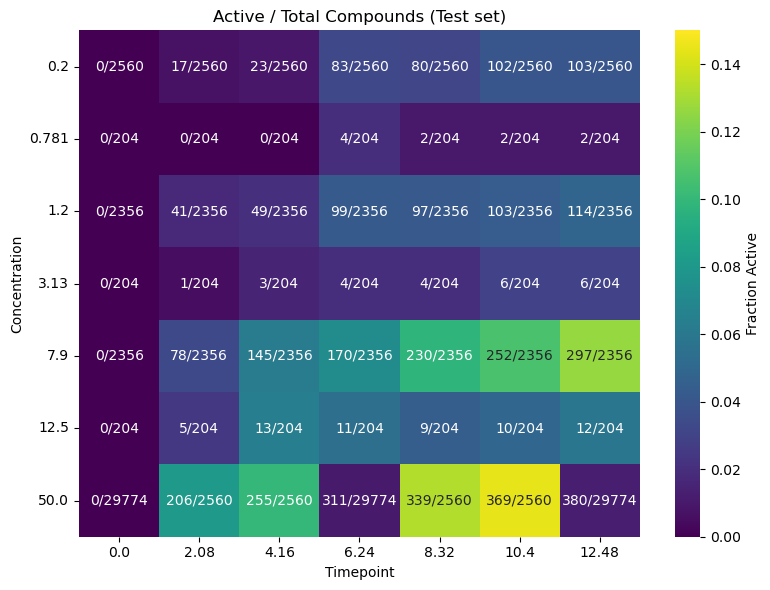

In [11]:
import seaborn as sns

def plot_activity_ratio_heatmap(df):
    # 1) Determine the exact list of concentrations and timepoints, in sorted order
    conc_values = sorted(df['Concentration'].unique())
    time_values = sorted(df['Timepoint'].unique())

    # 2) Build the “total” and “active” count tables, then reindex so they share the same shape/order
    total_counts = (
        df
        .groupby(['Concentration', 'Timepoint'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=conc_values, columns=time_values, fill_value=0)
    )

    active_counts = (
        df[df['is_Active'] == 1]
        .groupby(['Concentration', 'Timepoint'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=conc_values, columns=time_values, fill_value=0)
        .astype(int)
    )

    # 3) Compute fraction = active / total (avoiding division by zero)
    fraction = active_counts.divide(total_counts.replace(0, 1))
    fraction = fraction.fillna(0)

    # 4) Prepare annotation strings “active/total”
    annot = active_counts.astype(str) + "/" + total_counts.astype(str)

    # 5) Plot
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        fraction,
        annot=annot,
        fmt="",
        cmap="viridis",
        vmin=0,
        vmax=0.15,
        cbar_kws={'label': 'Fraction Active'}
    )

    # 6) Set the x‐ and y‐tick labels to the string versions of the numeric values
    ax.set_xticklabels([str(x) for x in time_values])
    ax.set_yticklabels([str(x) for x in conc_values], rotation=0)

    ax.set_xlabel('Timepoint')
    ax.set_ylabel('Concentration')
    ax.set_title('Active / Total Compounds (Test set)')

    plt.tight_layout()
    plt.show()
#plot_activity_ratio_heatmap(df_train),
plot_activity_ratio_heatmap(df_train_new)

In [11]:
summary = (
    df_train_new
    .groupby("Compound")
    .agg(
        n_unique_conc=("Concentration", "nunique"),
        n_unique_time=("Timepoint", "nunique")
    )
    .reset_index()
    .sort_values(["n_unique_conc", "n_unique_time"], ascending=[True, True])
)
summary['n_unique_conc'].value_counts()

n_unique_conc
1    27214
4     2356
5      204
Name: count, dtype: int64

Drop train compounds at concentrations 0.781, 3.13 and 12.5

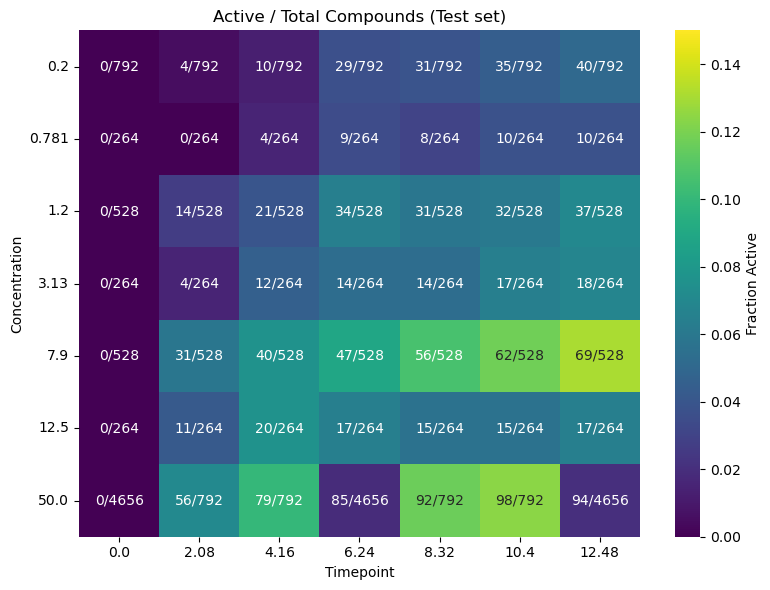

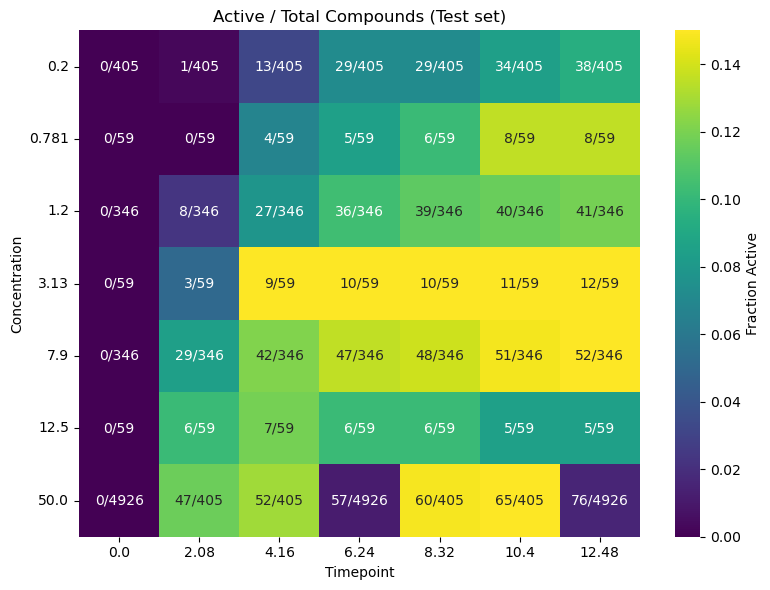

(None, None)

In [12]:
plot_activity_ratio_heatmap(df_val), plot_activity_ratio_heatmap(df_val_new)

In [17]:
subset = df_val_new[(df_val_new["is_Active"] == 1)]

print("Contains NaN OD:", subset["OD"].isna().any())
print("OD variance:", subset["OD"].var())

Contains NaN OD: False
OD variance: 0.07403911747652592


In [26]:
df_val_new[(df_val_new["is_Active"] == 0) & (df_val_new['OD'])<0.2]

,Well,Plate_ID,Concentration,Compound,Control_Label,Smiles,Timepoint,OD,is_Active,scaffold,maccs_fp,ecfp_fp,rdkit_fp,Smiles_canonical
11,A16,546,0.2,BTZ043 (Racemate),0,O=C1N=C(N(CC2)CCC32OCC(C)O3)SC4=C([N+]([O-])=O...,0.0,0.0,0,O=c1nc(N2CCC3(CC2)OCCO3)sc2ccccc12,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, ...",CC1COC2(CCN(c3nc(=O)c4cc(C(F)(F)F)cc([N+](=O)[...
16,A22,546,0.2,LtaS-IN-1,0,O=C(OCC(NC1=NN=C(C2=CC=CC=C2)O1)=O)CC3=COC4=CC...,0.0,0.0,0,O=C(COC(=O)Cc1coc2ccc3ccccc3c12)Nc1nnc(-c2cccc...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, ...",O=C(COC(=O)Cc1coc2ccc3ccccc3c12)Nc1nnc(-c2cccc...
37,C08,546,0.2,Resveratrol,0,OC1=CC=C(/C=C/C2=CC(O)=CC(O)=C2)C=C1,0.0,0.0,0,C(=Cc1ccccc1)c1ccccc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",Oc1ccc(/C=C/c2cc(O)cc(O)c2)cc1
41,C15,546,0.2,ABMA,0,COC1=CC=C(Br)C=C1CNC2(C3)CC4CC3CC(C4)C2,0.0,0.0,0,c1ccc(CNC23CC4CC(CC(C4)C2)C3)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",COc1ccc(Br)cc1CNC12CC3CC(CC(C3)C1)C2
50,D06,546,0.2,Sarafloxacin (hydrochloride),0,O=C(C1=CN(C2=CC=C(F)C=C2)C3=C(C=C(F)C(N4CCNCC4...,0.0,0.0,0,O=c1ccn(-c2ccccc2)c2cc(N3CCNCC3)ccc12,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, ...",Cl.O=C(O)c1cn(-c2ccc(F)cc2)c2cc(N3CCNCC3)c(F)c...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180051,NaN,1886318-Y12-A099,50.0,Z234897591,0,NCCC=1C=CC(=CC1)N2CCCCC2,0.0,0.0,0,c1ccc(N2CCCCC2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, ...",NCCc1ccc(N2CCCCC2)cc1
180066,NaN,1886318-Y12-A099,50.0,Z5435122112,0,NCC1CC(O)(CNC(=O)C=2C=CN3C(=O)NN=C3C2)C1,0.0,0.0,0,O=C(NCC1CCC1)c1ccn2c(=O)[nH]nc2c1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, ...",NCC1CC(O)(CNC(=O)c2ccn3c(=O)[nH]nc3c2)C1
180075,NaN,1886318-Y12-A099,50.0,Z5592615749,0,CCC1=CSC(=N1)N2C=C(C=N2)C(=O)N3CCOC=4C=CC(CN)=...,0.0,0.0,0,O=C(c1cnn(-c2nccs2)c1)N1CCOc2ccccc21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, ...",CCc1csc(-n2cc(C(=O)N3CCOc4ccc(CN)cc43)cn2)n1
180108,NaN,1886318-Y12-A100,50.0,Z4956890705,0,CC1CCC(CN)CN1C=2C=C(C)N=C(N2)N(C)C=3C=CC=CC3,0.0,0.0,0,c1ccc(Nc2nccc(N3CCCCC3)n2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, ...",Cc1cc(N2CC(CN)CCC2C)nc(N(C)c2ccccc2)n1


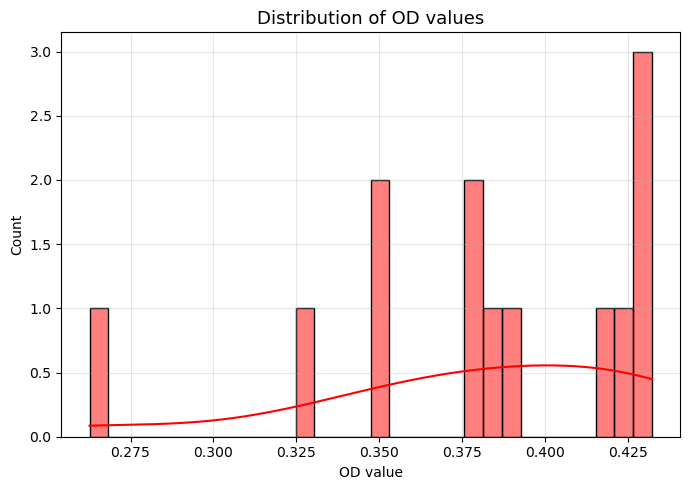

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter to actives at 0.2 µM
mask = (df_val_new["is_Active"] == 1) & (df_val_new["Concentration"] == 0.2) & (df_val_new['Timepoint'] == 4.16)
subset = df_val_new[mask]

# Plot
plt.figure(figsize=(7, 5))
sns.histplot(subset["OD"], bins=30, kde=True, color="red", edgecolor="black")

plt.title("Distribution of OD values", fontsize=13)
plt.xlabel("OD value")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [45]:
pd.to_pickle(df_train_new, "/home/ethan2/GrowthCurve/data/train/df_well_train_Celine_clusters_mad_4.pkl")
pd.to_pickle(df_val_new, "/home/ethan2/GrowthCurve/data/validation/df_well_validation_Celine_clusters_mad_4.pkl")

# Tanomoto similarity comp

In [29]:
df_train_new.columns

Index(['Well', 'Plate_ID', 'Concentration', 'Compound', 'Control_Label',
       'Smiles', 'Timepoint', 'OD', 'is_Active', 'scaffold', 'maccs_fp',
       'ecfp_fp', 'rdkit_fp', 'Smiles_canonical'],
      dtype='object')

In [30]:
df_val_new.columns

Index(['Well', 'Plate_ID', 'Concentration', 'Compound', 'Control_Label',
       'Smiles', 'Timepoint', 'OD', 'is_Active', 'scaffold', 'maccs_fp',
       'ecfp_fp', 'rdkit_fp', 'Smiles_canonical'],
      dtype='object')

In [34]:
df_train_new

,Well,Plate_ID,Concentration,Compound,Control_Label,Smiles,Timepoint,OD,is_Active,scaffold,maccs_fp,ecfp_fp,rdkit_fp,Smiles_canonical,concat_fp
0,A04,546,0.2,Lefamulin (acetate),0,CC(O)=O.C[C@@H]1C23[C@](C(CC3)=O)([H])C([C@H](...,0.00,0.000000,0,O=C(CSC1CCCCC1)OC1CCCCC23CCCC1C2C(=O)CC3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, ...",C=C[C@]1(C)C[C@@H](OC(=O)CS[C@@H]2CC[C@@H](N)C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,A05,546,0.2,Cefodizime (sodium),0,O=C(C(N12)=C(CSC3=NC(C)=C(CC(O[Na])=O)S3)CS[C@...,0.00,0.000000,0,N=C(C(=O)NC1C(=O)N2C=C(CSc3nccs3)CSC12)c1cscn1,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, ...","[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, ...",CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O[Na])=C(CS...,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, ..."
2,A07,546,0.2,Potassium guaiacolsulfonate (hemihydrate),0,COC1=CC(S(=O)(O[K])=O)=CC=C1O.COC2=C(C=CC=C2O)...,0.00,0.000000,0,c1ccccc1.c1ccccc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",COc1c(O)cccc1S(=O)(=O)O[K].COc1cc(S(=O)(=O)O[K...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,A08,546,0.2,Morinidazole (R enantiomer),0,O[C@@H](CN1C([N+]([O-])=O)=CN=C1C)CN2CCOCC2,0.00,0.000000,0,c1cn(CCCN2CCOCC2)cn1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",Cc1ncc([N+](=O)[O-])n1C[C@H](O)CN1CCOCC1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,A09,546,0.2,Pretomanid,0,FC(F)(F)OC(C=C1)=CC=C1CO[C@@H]2COC3=NC([N+]([O...,0.00,0.000000,0,c1ccc(COC2COc3nccn3C2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, ...",O=[N+]([O-])c1cn2c(n1)OC[C@@H](OCc1ccc(OC(F)(F...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180127,NaN,1886318-Y12-A100,50.0,Z6064857766,0,CC=1C=C(CN)C=C(NC(=O)C(O)CC=2C=CC=CC2Cl)C1,6.24,0.521312,0,O=C(CCc1ccccc1)Nc1ccccc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, ...",Cc1cc(CN)cc(NC(=O)C(O)Cc2ccccc2Cl)c1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
180128,NaN,1886318-Y12-A100,50.0,Z6064857766,0,CC=1C=C(CN)C=C(NC(=O)C(O)CC=2C=CC=CC2Cl)C1,12.48,0.936651,0,O=C(CCc1ccccc1)Nc1ccccc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, ...",Cc1cc(CN)cc(NC(=O)C(O)Cc2ccccc2Cl)c1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
180129,NaN,1886318-Y12-A100,50.0,Z8403626522,0,NCC=1C=C(NN1)C(=O)N2CC=3C=CC=C(Cl)C3C2,0.00,0.000000,0,O=C(c1ccn[nH]1)N1Cc2ccccc2C1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, ...",NCc1cc(C(=O)N2Cc3cccc(Cl)c3C2)[nH]n1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
180130,NaN,1886318-Y12-A100,50.0,Z8403626522,0,NCC=1C=C(NN1)C(=O)N2CC=3C=CC=C(Cl)C3C2,6.24,0.565833,0,O=C(c1ccn[nH]1)N1Cc2ccccc2C1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, ...",NCc1cc(C(=O)N2Cc3cccc(Cl)c3C2)[nH]n1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
'''
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datamol as dm

# --- Step 1: Deduplicate by canonical SMILES ---
# Keep one representative row per unique molecule
df_train_unique = df_train_new.drop_duplicates(subset=["Smiles_canonical"]).reset_index(drop=True)
df_val_unique   = df_val_new.drop_duplicates(subset=["Smiles_canonical"]).reset_index(drop=True)

# --- Step 2: Concatenate fingerprints ---
def concat_fps(row):
    fps = [row["maccs_fp"], row["ecfp_fp"], row["rdkit_fp"]]
    valid_fps = [fp for fp in fps if isinstance(fp, np.ndarray)]
    if not valid_fps:
        return None
    return np.concatenate(valid_fps)

df_train_unique["concat_fp"] = df_train_unique.apply(concat_fps, axis=1)
df_val_unique["concat_fp"]   = df_val_unique.apply(concat_fps, axis=1)

# Drop molecules without valid fingerprints
df_train_fp = df_train_unique.dropna(subset=["concat_fp"]).reset_index(drop=True)
df_val_fp   = df_val_unique.dropna(subset=["concat_fp"]).reset_index(drop=True)

train_fps = df_train_fp["concat_fp"].tolist()
val_fps   = df_val_fp["concat_fp"].tolist()

# --- Step 3: Compute similarity matrix (safe version) ---
try:
    from datamol.fp import similarity_matrix
    similarity_matrix = similarity_matrix(train_fps, val_fps, metric="tanimoto")
except Exception:
    # Manual fallback if datamol.fp.similarity_matrix is unavailable
    def similarity_matrix(X, Y):
        sims = np.zeros((len(X), len(Y)))
        for i, xi in enumerate(X):
            for j, yj in enumerate(Y):
                inter = np.logical_and(xi, yj).sum()
                union = np.logical_or(xi, yj).sum()
                sims[i, j] = inter / union if union > 0 else 0.0
        return sims
    similarity_matrix = similarity_matrix(train_fps, val_fps)

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, cmap="viridis", vmin=0, vmax=1,
            xticklabels=df_val_fp["Compound"].values,
            yticklabels=df_train_fp["Compound"].values)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Tanimoto Similarity Between Unique Train and Validation Compounds", fontsize=14)
plt.xlabel("Validation Compounds")
plt.ylabel("Training Compounds")
plt.tight_layout()

# --- Step 5: Save to file ---
save_path = "/home/ethan2/GrowthCurve/plots/tanimoto_sim.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"✅ Heatmap saved to: {save_path}")
'''


KeyboardInterrupt: 

analyze Celines train 

In [1]:
import pickle

# --- Load pickled CompoundMeta list ---
with open("/home/ethan2/GrowthCurve/data/train/Celine_CompoundMetas_list.pkl", "rb") as f:
    metas = pickle.load(f)

AttributeError: Can't get attribute 'CompoundMeta' on <module '__main__'>

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df_val   = pd.read_pickle("/home/ethan2/GrowthCurve/data/validation/df_well_validation_Celine_clusters_mad_4.pkl")


In [11]:
df_val

,Well,Plate_ID,Concentration,Compound,Control_Label,Smiles,Timepoint,OD,is_Active,scaffold,maccs_fp,ecfp_fp,rdkit_fp,Smiles_canonical
11,A16,546,0.2,BTZ043 (Racemate),0,O=C1N=C(N(CC2)CCC32OCC(C)O3)SC4=C([N+]([O-])=O...,0.00,0.000000,0,O=c1nc(N2CCC3(CC2)OCCO3)sc2ccccc12,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, ...",CC1COC2(CCN(c3nc(=O)c4cc(C(F)(F)F)cc([N+](=O)[...
16,A22,546,0.2,LtaS-IN-1,0,O=C(OCC(NC1=NN=C(C2=CC=CC=C2)O1)=O)CC3=COC4=CC...,0.00,0.000000,0,O=C(COC(=O)Cc1coc2ccc3ccccc3c12)Nc1nnc(-c2cccc...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, ...",O=C(COC(=O)Cc1coc2ccc3ccccc3c12)Nc1nnc(-c2cccc...
37,C08,546,0.2,Resveratrol,0,OC1=CC=C(/C=C/C2=CC(O)=CC(O)=C2)C=C1,0.00,0.000000,0,C(=Cc1ccccc1)c1ccccc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",Oc1ccc(/C=C/c2cc(O)cc(O)c2)cc1
41,C15,546,0.2,ABMA,0,COC1=CC=C(Br)C=C1CNC2(C3)CC4CC3CC(C4)C2,0.00,0.000000,0,c1ccc(CNC23CC4CC(CC(C4)C2)C3)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",COc1ccc(Br)cc1CNC12CC3CC(CC(C3)C1)C2
50,D06,546,0.2,Sarafloxacin (hydrochloride),0,O=C(C1=CN(C2=CC=C(F)C=C2)C3=C(C=C(F)C(N4CCNCC4...,0.00,0.000000,0,O=c1ccn(-c2ccccc2)c2cc(N3CCNCC3)ccc12,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, ...",Cl.O=C(O)c1cn(-c2ccc(F)cc2)c2cc(N3CCNCC3)c(F)c...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180109,NaN,1886318-Y12-A100,50.0,Z4956890705,0,CC1CCC(CN)CN1C=2C=C(C)N=C(N2)N(C)C=3C=CC=CC3,6.24,0.572416,0,c1ccc(Nc2nccc(N3CCCCC3)n2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, ...",Cc1cc(N2CC(CN)CCC2C)nc(N(C)c2ccccc2)n1
180110,NaN,1886318-Y12-A100,50.0,Z4956890705,0,CC1CCC(CN)CN1C=2C=C(C)N=C(N2)N(C)C=3C=CC=CC3,12.48,0.986946,0,c1ccc(Nc2nccc(N3CCCCC3)n2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, ...",Cc1cc(N2CC(CN)CCC2C)nc(N(C)c2ccccc2)n1
180123,NaN,1886318-Y12-A100,50.0,Z5594715074,0,CC1=C(CN)C(NC(=O)C2=CC=C(NC2=O)C3=CC=CS3)=NN1C,0.00,0.000000,0,O=C(Nc1cc[nH]n1)c1ccc(-c2cccs2)[nH]c1=O,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, ...",Cc1c(CN)c(NC(=O)c2ccc(-c3cccs3)[nH]c2=O)nn1C
180124,NaN,1886318-Y12-A100,50.0,Z5594715074,0,CC1=C(CN)C(NC(=O)C2=CC=C(NC2=O)C3=CC=CS3)=NN1C,6.24,0.562935,0,O=C(Nc1cc[nH]n1)c1ccc(-c2cccs2)[nH]c1=O,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, ...",Cc1c(CN)c(NC(=O)c2ccc(-c3cccs3)[nH]c2=O)nn1C


In [12]:
df_val["concat_fp"] = df_val.apply(
    lambda row: np.concatenate([
        np.array(row["maccs_fp"], dtype=np.uint8),
        np.array(row["ecfp_fp"], dtype=np.uint8),
        np.array(row["rdkit_fp"], dtype=np.uint8)
    ]),
    axis=1
)

# Confirm
print(df_val["concat_fp"].iloc[0].shape)
print(df_val[["maccs_fp", "ecfp_fp", "rdkit_fp", "concat_fp"]].head(1))

(4263,)
                                             maccs_fp  \
11  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                              ecfp_fp  \
11  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                             rdkit_fp  \
11  [1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, ...   

                                            concat_fp  
11  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  


In [15]:
df_val['Smiles_canonical'].nunique()

4925

In [16]:
import numpy as np

# Convert each fingerprint vector into a tuple (hashable) for comparison
df_val["concat_fp_tuple"] = df_val["concat_fp"].apply(lambda x: tuple(x.tolist()))

# Count unique vectors
n_unique_fp = df_val["concat_fp_tuple"].nunique()
n_unique_smiles = df_val["Smiles_canonical"].nunique()

print(f"Unique canonical SMILES: {n_unique_smiles}")
print(f"Unique concatenated fingerprint vectors: {n_unique_fp}")

# Optional sanity check: they should match
if n_unique_fp == n_unique_smiles:
    print("✅ Fingerprints are consistent: one unique vector per unique SMILES.")
else:
    print("⚠️ Mismatch detected: some unique SMILES share identical fingerprints.")


Unique canonical SMILES: 4925
Unique concatenated fingerprint vectors: 4918
⚠️ Mismatch detected: some unique SMILES share identical fingerprints.


In [17]:
# Count how many unique canonical SMILES have at least one active measurement
active_smiles = (
    df_val.groupby("Smiles_canonical")["is_Active"]
    .max()              # if any row = 1 → max = 1
    .reset_index()
)

n_active = (active_smiles["is_Active"] == 1).sum()
n_total = active_smiles.shape[0]
frac_active = n_active / n_total

print(f"Unique compounds: {n_total}")
print(f"Compounds with ≥1 active measurement: {n_active}")
print(f"Fraction active: {frac_active:.2%}")


Unique compounds: 4925
Compounds with ≥1 active measurement: 113
Fraction active: 2.29%
